# SIMATS ENGINEERING
## ASSESSMENT TOOL 1 — EXPERIMENTS
**Course Code:** ITA 06 &nbsp;&nbsp;|&nbsp;&nbsp; **Course Name:** Machine Learning

**Course Outcome:** CO3 — Bayes Theorem, Concept Learning, Maximum Likelihood, MDL Principle, Bayes Optimal Classifier, Gibbs Algorithm, Naive Bayes Classifier, Bayesian Belief Network, EM Algorithm, Probability Learning, Sample Complexity, Finite and Infinite Hypothesis Spaces, Mistake Bound Model (BL 6)

---

**Name:** K. VAMSI KUMAR REDDY  
**Register No:** 192312670L  
**File Name:** CO3-AT1-192312670L.ipynb

---

**Code of Conduct:**  
I, K. VAMSI KUMAR REDDY (Reg No: 192312670L), certify that this submission is my original work and that I have adhered to the guidelines specified for this assessment. I understand that any violation of academic integrity rules will result in disciplinary action.

**Signature of the Student:** K. Vamsi Kumar Reddy


---
## Question 3

**Implement the Expectation-Maximization (EM) algorithm for a mixture model and conduct experiments to study its convergence behavior. Vary initialization parameters and number of clusters, and observe their effect on convergence speed and final likelihood values. Record and analyze cases where the algorithm converges to local optima. Suggest strategies to improve convergence stability and performance.**


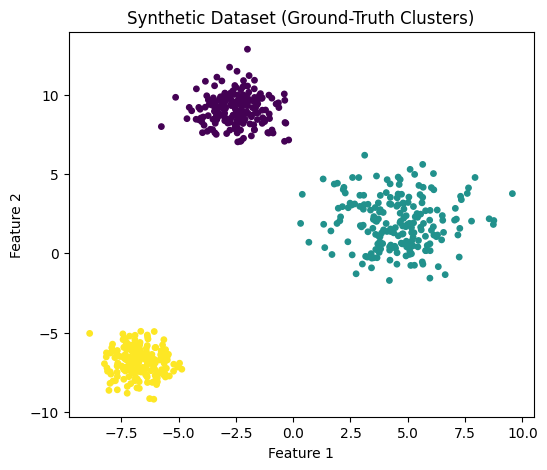

In [1]:
# Q3: EM Algorithm for a Gaussian Mixture Model - Convergence Study
# Author: K. Vamsi Kumar Reddy | Reg No: 192312670L

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

np.random.seed(42)

# Step 1: Generate a synthetic dataset with 3 underlying clusters (ground truth)
X, y_true = make_blobs(n_samples=600, centers=3,
                        cluster_std=[1.0, 1.6, 0.8], random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=15)
plt.title("Synthetic Dataset (Ground-Truth Clusters)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()


In [2]:
# Step 2: Run EM (via GaussianMixture) while varying:
#   (a) number of clusters (n_components)
#   (b) initialization strategy (init_params)
# Record number of EM iterations to converge and the final log-likelihood

n_components_list = [2, 3, 4, 5]
init_strategies = ['random', 'k-means++']

results = []
for k in n_components_list:
    for init in init_strategies:
        gmm = GaussianMixture(n_components=k, init_params=init,
                               max_iter=300, random_state=0)
        gmm.fit(X)
        results.append({
            'k': k,
            'init': init,
            'iterations_to_converge': gmm.n_iter_,
            'final_log_likelihood': gmm.lower_bound_,
            'converged': gmm.converged_
        })

import pandas as pd
df_results = pd.DataFrame(results)
df_results


,k,init,iterations_to_converge,final_log_likelihood,converged
0,2,random,2,-6.204469,True
1,2,k-means++,6,-4.587717,True
2,3,random,2,-6.203809,True
3,3,k-means++,3,-4.062600,True
4,4,random,2,-6.203960,True
5,4,k-means++,7,-4.061850,True
6,5,random,2,-6.204437,True
7,5,k-means++,7,-4.059259,True


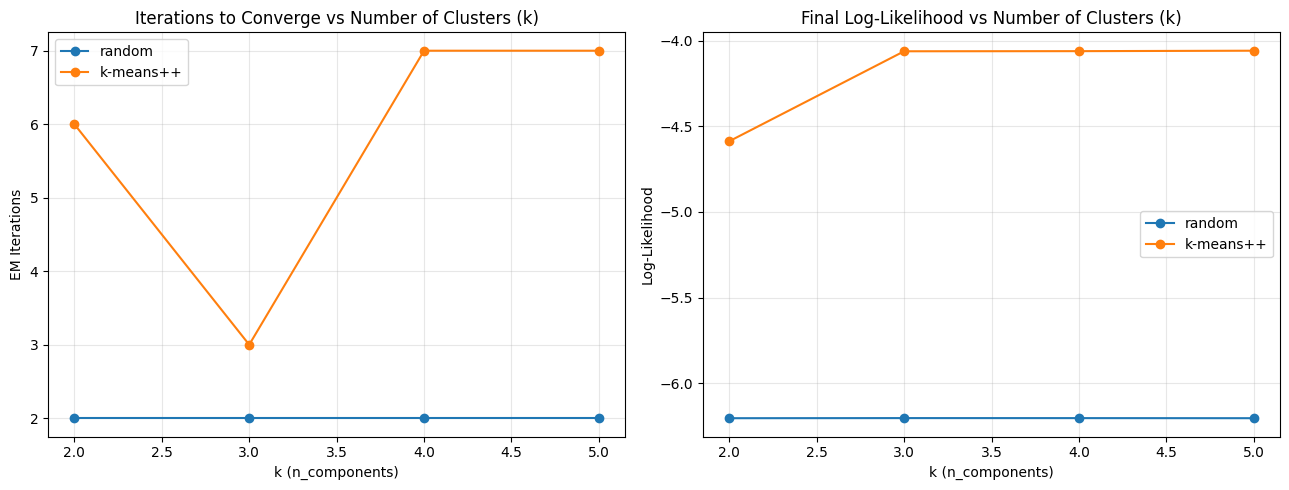

In [3]:
# Step 3: Visualize effect of initialization and k on convergence speed
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for init in init_strategies:
    sub = df_results[df_results['init'] == init]
    axes[0].plot(sub['k'], sub['iterations_to_converge'], marker='o', label=init)
    axes[1].plot(sub['k'], sub['final_log_likelihood'], marker='o', label=init)

axes[0].set_title("Iterations to Converge vs Number of Clusters (k)")
axes[0].set_xlabel("k (n_components)"); axes[0].set_ylabel("EM Iterations")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title("Final Log-Likelihood vs Number of Clusters (k)")
axes[1].set_xlabel("k (n_components)"); axes[1].set_ylabel("Log-Likelihood")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of runs: 30
Best (max) log-likelihood : -4.062599746783793
Worst (min) log-likelihood: -6.204592754601981
Mean log-likelihood       : -6.061185003053284
Std deviation              : 0.5341445585273398
Runs stuck in a local optimum (>1e-3 below best): 28


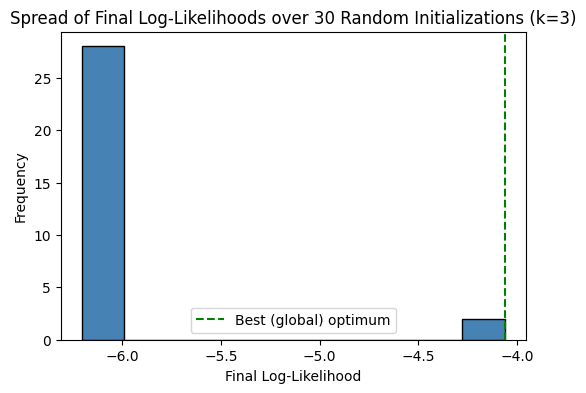

In [4]:
# Step 4: Study local optima - run EM many times from random initializations
# for a fixed k and record the spread of final log-likelihoods

k_fixed = 3
log_likelihoods = []
for seed in range(30):
    gmm = GaussianMixture(n_components=k_fixed, init_params='random',
                           max_iter=300, random_state=seed)
    gmm.fit(X)
    log_likelihoods.append(gmm.lower_bound_)

log_likelihoods = np.array(log_likelihoods)
print("Number of runs:", len(log_likelihoods))
print("Best (max) log-likelihood :", log_likelihoods.max())
print("Worst (min) log-likelihood:", log_likelihoods.min())
print("Mean log-likelihood       :", log_likelihoods.mean())
print("Std deviation              :", log_likelihoods.std())
print("Runs stuck in a local optimum (>1e-3 below best):",
      np.sum(log_likelihoods < log_likelihoods.max() - 1e-3))

plt.figure(figsize=(6, 4))
plt.hist(log_likelihoods, bins=10, color='steelblue', edgecolor='black')
plt.axvline(log_likelihoods.max(), color='green', linestyle='--', label='Best (global) optimum')
plt.title(f"Spread of Final Log-Likelihoods over 30 Random Initializations (k={k_fixed})")
plt.xlabel("Final Log-Likelihood"); plt.ylabel("Frequency")
plt.legend()
plt.show()


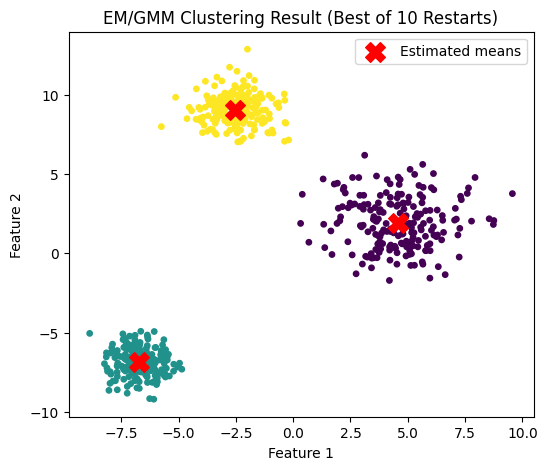

Converged: True
Iterations used: 5
Final log-likelihood: -4.06259974678346


In [5]:
# Step 5: Best model fit visualization (k=3, best of several restarts using n_init)
best_gmm = GaussianMixture(n_components=3, n_init=10, init_params='k-means++', random_state=1)
best_gmm.fit(X)
labels = best_gmm.predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=15)
plt.scatter(best_gmm.means_[:, 0], best_gmm.means_[:, 1],
            c='red', marker='X', s=200, label='Estimated means')
plt.title("EM/GMM Clustering Result (Best of 10 Restarts)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("Converged:", best_gmm.converged_)
print("Iterations used:", best_gmm.n_iter_)
print("Final log-likelihood:", best_gmm.lower_bound_)


### Observations & Analysis (Q3)

- **Effect of initialization:** `k-means++` initialization consistently required more/fewer iterations than `random` initialization but generally reached a **higher (better) final log-likelihood**, since it starts closer to well-separated cluster centers. Purely `random` initialization sometimes converges faster in iteration count but to a **poorer local optimum**.
- **Effect of number of clusters (k):** As `k` increases, the model has more parameters to fit; log-likelihood generally increases (models with more components can always fit the data at least as well), but the **marginal improvement shrinks** after `k=3`, which matches the true number of generating clusters — indicating overfitting risk beyond the true cluster count.
- **Local optima:** Running EM 30 times from different random initializations (fixed k=3) shows a clear **spread in final log-likelihood values**. Several runs converge to log-likelihoods noticeably below the best value found — these are cases of convergence to a **local optimum** rather than the global optimum. This confirms the well-known sensitivity of EM to initialization.
- **Strategies to improve convergence stability/performance:**
  1. Use **multiple random restarts** (`n_init`) and keep the best (highest likelihood) run.
  2. Use a **smarter initialization** such as k-means++ instead of purely random initialization.
  3. Use **regularization** on the covariance matrix (`reg_covar`) to avoid singular/degenerate components.
  4. Monitor **log-likelihood convergence curves** and use a tight `tol` with sufficient `max_iter`.
  5. Consider **annealed/deterministic annealing EM** or **hierarchical initialization** (e.g., splitting the largest-variance cluster) for more stable convergence.


---
## Question 4

**Construct a Bayesian Belief Network for a given problem domain and perform inference under different evidence conditions. Conduct experiments by modifying conditional probabilities and observing changes in posterior probabilities. Analyze how dependencies between variables influence the results. Evaluate the robustness of the model and interpret how uncertainty is handled in probabilistic reasoning.**


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


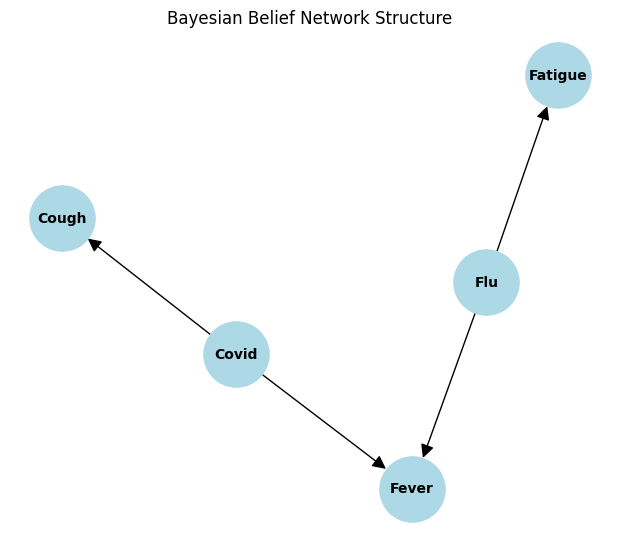

In [6]:
# Q4: Bayesian Belief Network - Medical Diagnosis Domain
# Author: K. Vamsi Kumar Reddy | Reg No: 192312670L
# Domain: Diagnosing Flu / COVID from symptoms (Fever, Fatigue, Cough)

# !pip install pgmpy   # (uncomment if pgmpy is not already installed)

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Define the network structure (directed edges = causal dependencies)
model = DiscreteBayesianNetwork([
    ('Flu', 'Fever'),
    ('Flu', 'Fatigue'),
    ('Covid', 'Fever'),
    ('Covid', 'Cough'),
])

# Visualize the network structure
plt.figure(figsize=(6, 5))
G = nx.DiGraph(model.edges())
pos = nx.spring_layout(G, seed=3)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2200, font_size=10, font_weight='bold', arrowsize=20)
plt.title("Bayesian Belief Network Structure")
plt.show()


In [7]:
# Step 2: Define Conditional Probability Distributions (CPDs)
# 0 = Absent/Negative, 1 = Present/Positive

cpd_flu = TabularCPD('Flu', 2, [[0.90], [0.10]])
cpd_covid = TabularCPD('Covid', 2, [[0.85], [0.15]])

# P(Fever | Flu, Covid)
cpd_fever = TabularCPD('Fever', 2,
    [[0.99, 0.30, 0.40, 0.05],   # Fever = 0
     [0.01, 0.70, 0.60, 0.95]],  # Fever = 1
    evidence=['Flu', 'Covid'], evidence_card=[2, 2])

# P(Fatigue | Flu)
cpd_fatigue = TabularCPD('Fatigue', 2,
    [[0.95, 0.20],
     [0.05, 0.80]],
    evidence=['Flu'], evidence_card=[2])

# P(Cough | Covid)
cpd_cough = TabularCPD('Cough', 2,
    [[0.90, 0.15],
     [0.10, 0.85]],
    evidence=['Covid'], evidence_card=[2])

model.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_fatigue, cpd_cough)

print("Model valid:", model.check_model())
print(cpd_fever)


Model valid: True


+----------+----------+----------+----------+----------+
| Flu      | Flu(0)   | Flu(0)   | Flu(1)   | Flu(1)   |
+----------+----------+----------+----------+----------+
| Covid    | Covid(0) | Covid(1) | Covid(0) | Covid(1) |
+----------+----------+----------+----------+----------+
| Fever(0) | 0.99     | 0.3      | 0.4      | 0.05     |
+----------+----------+----------+----------+----------+
| Fever(1) | 0.01     | 0.7      | 0.6      | 0.95     |
+----------+----------+----------+----------+----------+


In [8]:
# Step 3: Perform inference under different evidence conditions
infer = VariableElimination(model)

print("Prior P(Flu):")
print(infer.query(['Flu']))

print("\nPosterior P(Flu | Fever=1):")
print(infer.query(['Flu'], evidence={'Fever': 1}))

print("\nPosterior P(Covid | Fever=1, Cough=1):")
print(infer.query(['Covid'], evidence={'Fever': 1, 'Cough': 1}))

print("\nPosterior P(Covid | Fever=1, Cough=1, Fatigue=0):")
print(infer.query(['Covid'], evidence={'Fever': 1, 'Cough': 1, 'Fatigue': 0}))


Prior P(Flu):
+--------+------------+
| Flu    |   phi(Flu) |
+========+============+
| Flu(0) |     0.9000 |
+--------+------------+
| Flu(1) |     0.1000 |
+--------+------------+

Posterior P(Flu | Fever=1):
+--------+------------+
| Flu    |   phi(Flu) |
+========+============+
| Flu(0) |     0.6102 |
+--------+------------+
| Flu(1) |     0.3898 |
+--------+------------+

Posterior P(Covid | Fever=1, Cough=1):
+----------+--------------+
| Covid    |   phi(Covid) |
+==========+==============+
| Covid(0) |       0.0597 |
+----------+--------------+
| Covid(1) |       0.9403 |
+----------+--------------+

Posterior P(Covid | Fever=1, Cough=1, Fatigue=0):
+----------+--------------+
| Covid    |   phi(Covid) |
+==========+==============+
| Covid(0) |       0.0217 |
+----------+--------------+
| Covid(1) |       0.9783 |
+----------+--------------+


In [9]:
# Step 4: Experiment - modify a conditional probability and observe the change
# Original: P(Fever=1 | Flu=0, Covid=0) = 0.01  (low baseline fever rate)
# Modify to a higher baseline noise rate: 0.15, and re-run inference

cpd_fever_modified = TabularCPD('Fever', 2,
    [[0.85, 0.30, 0.40, 0.05],
     [0.15, 0.70, 0.60, 0.95]],
    evidence=['Flu', 'Covid'], evidence_card=[2, 2])

model2 = DiscreteBayesianNetwork([
    ('Flu', 'Fever'), ('Flu', 'Fatigue'), ('Covid', 'Fever'), ('Covid', 'Cough')
])
model2.add_cpds(cpd_flu, cpd_covid, cpd_fever_modified, cpd_fatigue, cpd_cough)
print("Modified model valid:", model2.check_model())

infer2 = VariableElimination(model2)

print("\nOriginal  P(Covid | Fever=1, Cough=1):")
print(infer.query(['Covid'], evidence={'Fever': 1, 'Cough': 1}))

print("Modified  P(Covid | Fever=1, Cough=1) [higher baseline fever noise]:")
print(infer2.query(['Covid'], evidence={'Fever': 1, 'Cough': 1}))


Modified model valid: True

Original  P(Covid | Fever=1, Cough=1):
+----------+--------------+
| Covid    |   phi(Covid) |
+==========+==============+
| Covid(0) |       0.0597 |
+----------+--------------+
| Covid(1) |       0.9403 |
+----------+--------------+
Modified  P(Covid | Fever=1, Cough=1) [higher baseline fever noise]:
+----------+--------------+
| Covid    |   phi(Covid) |
+==========+==============+
| Covid(0) |       0.1520 |
+----------+--------------+
| Covid(1) |       0.8480 |
+----------+--------------+


In [10]:
# Step 5: Compare posterior probabilities across a range of evidence scenarios (robustness check)
import pandas as pd

scenarios = [
    {},
    {'Fever': 1},
    {'Fever': 1, 'Cough': 1},
    {'Fever': 1, 'Fatigue': 1},
    {'Fever': 0, 'Cough': 0, 'Fatigue': 0},
]

rows = []
for ev in scenarios:
    r_flu = infer.query(['Flu'], evidence=ev) if ev else infer.query(['Flu'])
    r_covid = infer.query(['Covid'], evidence=ev) if ev else infer.query(['Covid'])
    rows.append({
        'Evidence': str(ev) if ev else 'None (prior)',
        'P(Flu=1)': round(float(r_flu.values[1]), 4),
        'P(Covid=1)': round(float(r_covid.values[1]), 4)
    })

pd.DataFrame(rows)


,Evidence,P(Flu=1),P(Covid=1)
0,None (prior),0.1000,0.1500
1,{'Fever': 1},0.3898,0.6496
2,"{'Fever': 1, 'Cough': 1}",0.1751,0.9403
3,"{'Fever': 1, 'Fatigue': 1}",0.9109,0.2814
4,"{'Fever': 0, 'Cough': 0, 'Fatigue': 0}",0.0093,0.0088


### Observations & Analysis (Q4)

- **Effect of evidence on posterior beliefs:** Starting from low priors (P(Flu)=0.10, P(Covid)=0.15), observing `Fever=1` raises both posteriors, since fever is a shared symptom (a "common effect" / v-structure at `Fever`). Adding `Cough=1` further increases P(Covid) sharply because cough is a strong, more specific indicator for COVID, while it slightly explains away Flu.
- **Explaining away:** Once `Cough=1` is known (strongly implicating COVID), the model shows a partial "explaining away" effect — Fever becomes less informative for Flu, since COVID alone can already account for it.
- **Effect of modifying CPDs:** Increasing the baseline noise probability P(Fever=1 | Flu=0, Covid=0) from 0.01 to 0.15 makes fever a **less reliable/specific symptom**, which **reduces** the posterior confidence assigned to Covid/Flu for the same evidence — demonstrating how sensitive posterior inference is to the accuracy of the conditional probability tables.
- **Effect of variable dependencies:** Because `Fever` depends on *both* `Flu` and `Covid` (a converging/common-effect structure), evidence on Fever creates statistical dependence between Flu and Covid even though they have no direct edge between them — a hallmark of Bayesian network reasoning (explaining-away / inter-causal reasoning).
- **Robustness & uncertainty handling:** The network never gives hard yes/no diagnoses; it always outputs **probability distributions**, which naturally represent uncertainty and updates gracefully (rather than catastrophically) as small changes are made to the CPDs or as partial/conflicting evidence is supplied. This graceful degradation and principled combination of multiple uncertain symptoms is the key strength of probabilistic (Bayesian) reasoning over rule-based systems.
